# Plotting Plate Model with PyGMT

Geological reconstruction is the process of reversing tectonic plate movements to visualize how Earth's surface appeared in the past. By applying plate motion models, we can "rewind" the positions of coastlines, continents, plate boundaries, and fossil locations to understand ancient geography and geological processes.

This notebook demonstrates how to create the same visualizations as notebook 2a, but using PyGMT instead of Matplotlib/Cartopy for plotting.

[PyGMT](https://www.pygmt.org/latest/) is the Python interface for the Generic Mapping Tools (GMT), widely used in geosciences for producing high-quality maps. Compared to Matplotlib/Cartopy, PyGMT is more specialized for geographic and geological data, offering clean syntax, professional cartographic styles, and seamless integration with Python workflows.

### Setup

Let's begin by importing the required packages:

In [ ]:
# Ensure you have the required packages installed:
# Run `pip install gplately pygmt` if not already installed.

import gplately
import pygmt
from gplately.auxiliary import get_gplot, get_pygmt_basemap_figure
from gplately.mapping.pygmt_plot import PygmtPlotEngine
from plate_model_manager import PlateModelManager

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

In [3]:
# Create a Plate Model Manager
pm_manager = PlateModelManager()

# Load & download model data into the path specified by 'data_dir'
# To load a specific model, you can specify the model name
try:
    muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")
except Exception as e:
    print(f"Error loading model: {e}")

# Fetch components of the loaded model
rotation_model_2019 = muller2019_model.get_rotation_model()
topology_features_2019 = muller2019_model.get_topologies()
static_polygons_2019 = muller2019_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model_2019, topology_features_2019, static_polygons_2019)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time = 200  # Ma

### Plotting Coastlines with PyGMT!

This code visualizes what Earth’s landmasses and coastlines looked like in the geological past (here, at a specified time such as 200 Ma) using GPlately’s PlotTopologies object and PyGMT for high-quality cartographic rendering.

- Reconstruct features: We retrieve both coastlines and continental outlines for the chosen geological time using `gplot.get_coastlines()` and `gplot.get_continents()`.

- Set up the PyGMT figure: A new PyGMT figure is created, and we define a global basemap `(region="d")` with a Plate Carrée projection `(projection="Q60c")`. The frame includes the map title showing the reconstruction time.

- Plot continents: The reconstructed continents are plotted as filled polygons with black outlines.

- Overlay coastlines: The reconstructed coastlines are drawn on top in bold black lines to emphasize the ancient shoreline positions.

- Display the map: The final figure presents a clean, global visualization of Earth's reconstructed geography for the chosen time.

The advantage of using PyGMT is its high-quality cartographic output and extensive mapping capabilities!

> `NOTE:` You’ll need to specify map projections using GMT-style syntax (e.g., "Q15c" for a 15 cm-wide Plate Carrée projection). If you’re new to GMT projections, check out the [PyGMT projections documentation](https://www.pygmt.org/v0.3.1/projections/index.html) for a helpful guide.

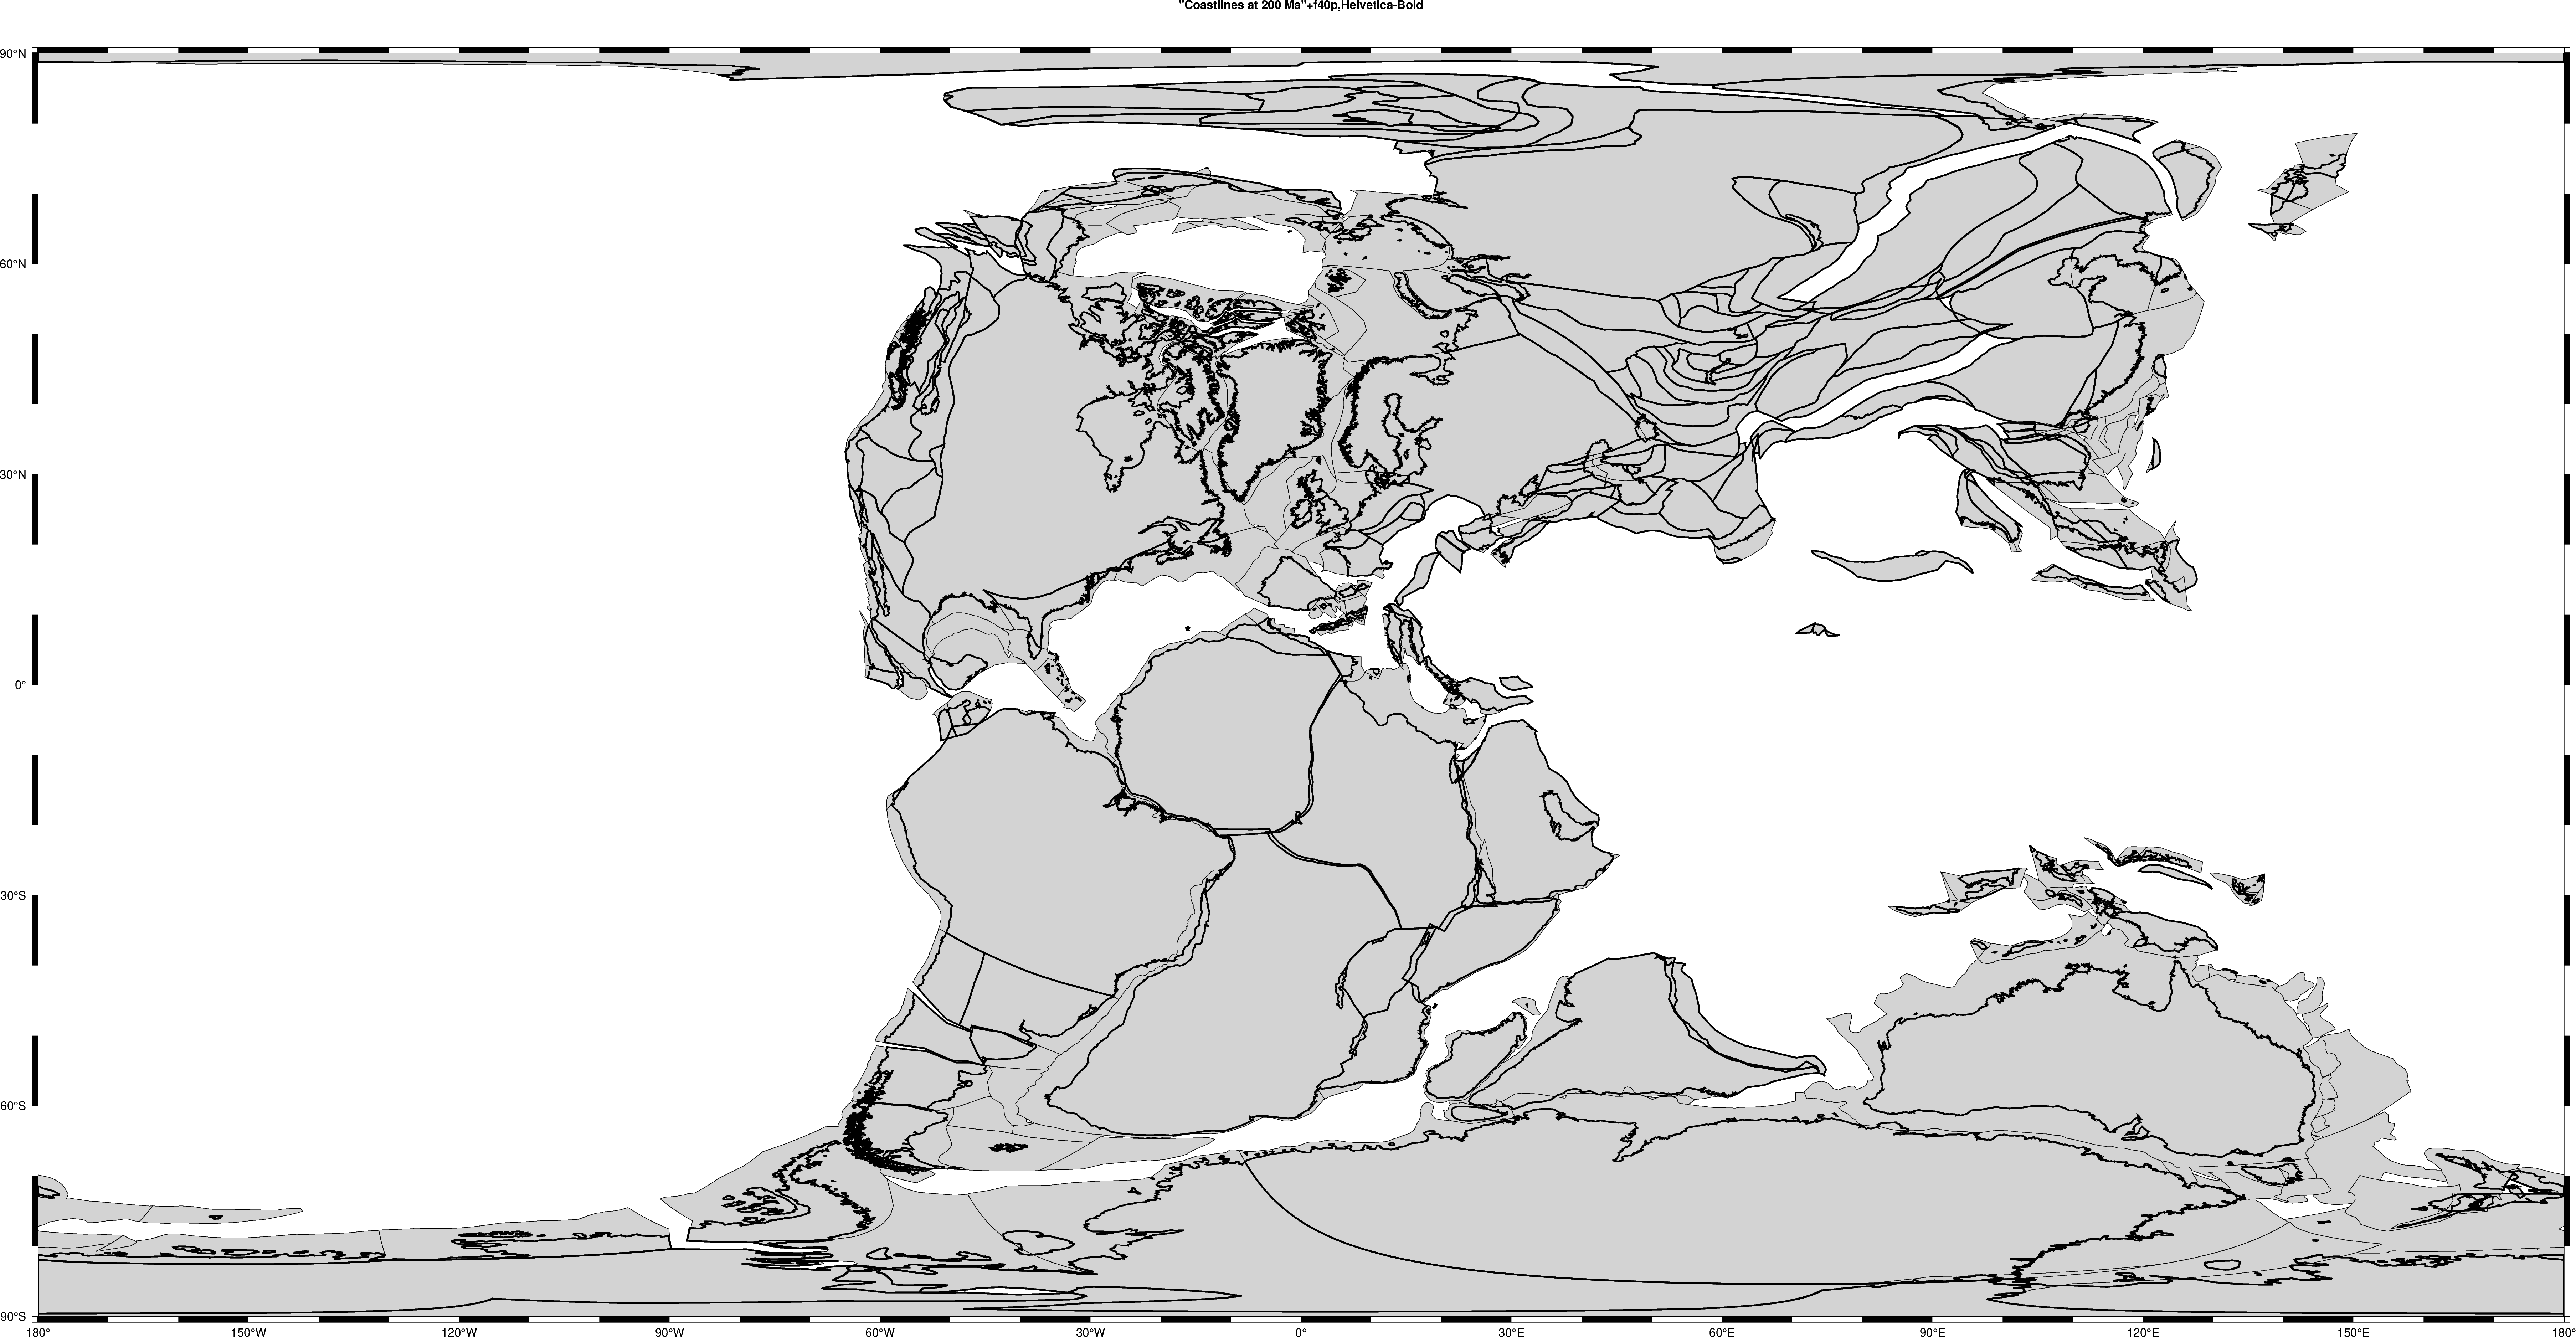

In [ ]:
# Get reconstructed coastlines and continents at the specified time
coastlines_gdf = gplot.get_coastlines()
continents_gdf = gplot.get_continents()

# Create a PyGMT figure
fig = pygmt.Figure()

# Plot basemap
fig.basemap(
    region="d",  # global: -180/180/-90/90
    projection="Q60c",  # PlateCarree projection, 15cm width
    frame=["af", f'+t"Coastlines at {time} Ma']
)

# Plot reconstructed continents (filled polygons)
if continents_gdf is not None and not continents_gdf.empty:
    fig.plot(
        data=continents_gdf,
        fill="lightgray",
        pen="0.25p,black"
    )

# Plot reconstructed coastlines on top
if coastlines_gdf is not None and not coastlines_gdf.empty:
    fig.plot(
        data=coastlines_gdf,
        pen="1p,black"
    )

# Show the figure
fig.show()

### Plotting Coastlines With Plate Boundaries

Let’s see another example, this time plotting both reconstructed coastlines and plate boundaries at 200 Ma.

- Reconstruct features: Now, we extract multiple geological layers (coastlines, continents, and plate boundary types (ridges, transforms, and trenches)) using GPlately functions.

- Set up the PyGMT figure: A global basemap (region="d") with a Plate Carrée projection (projection="Q15c") is created.

- Plot continents and coastlines: Continents are filled in tan with thin black outlines, while coastlines are drawn as black lines to highlight the reconstructed shorelines.

- Add plate boundaries: Ridges, transforms, and trenches are overlaid in red to clearly distinguish active tectonic zones and visualize the configuration of ancient plate boundaries.

- Display the map: The result is a clear, global paleogeographic view showing how continents and tectonic boundaries were arranged in deep time.

This way, you can see not just the ancient landmasses, but also how tectonic plate boundaries were arranged at the time.

> `NOTE:` You’ll need to specify map projections using GMT-style syntax (e.g., "Q15c" for a 15 cm-wide Plate Carrée projection). If you’re new to GMT projections, check out the [PyGMT projections documentation](https://www.pygmt.org/v0.3.1/projections/index.html) for a helpful guide.

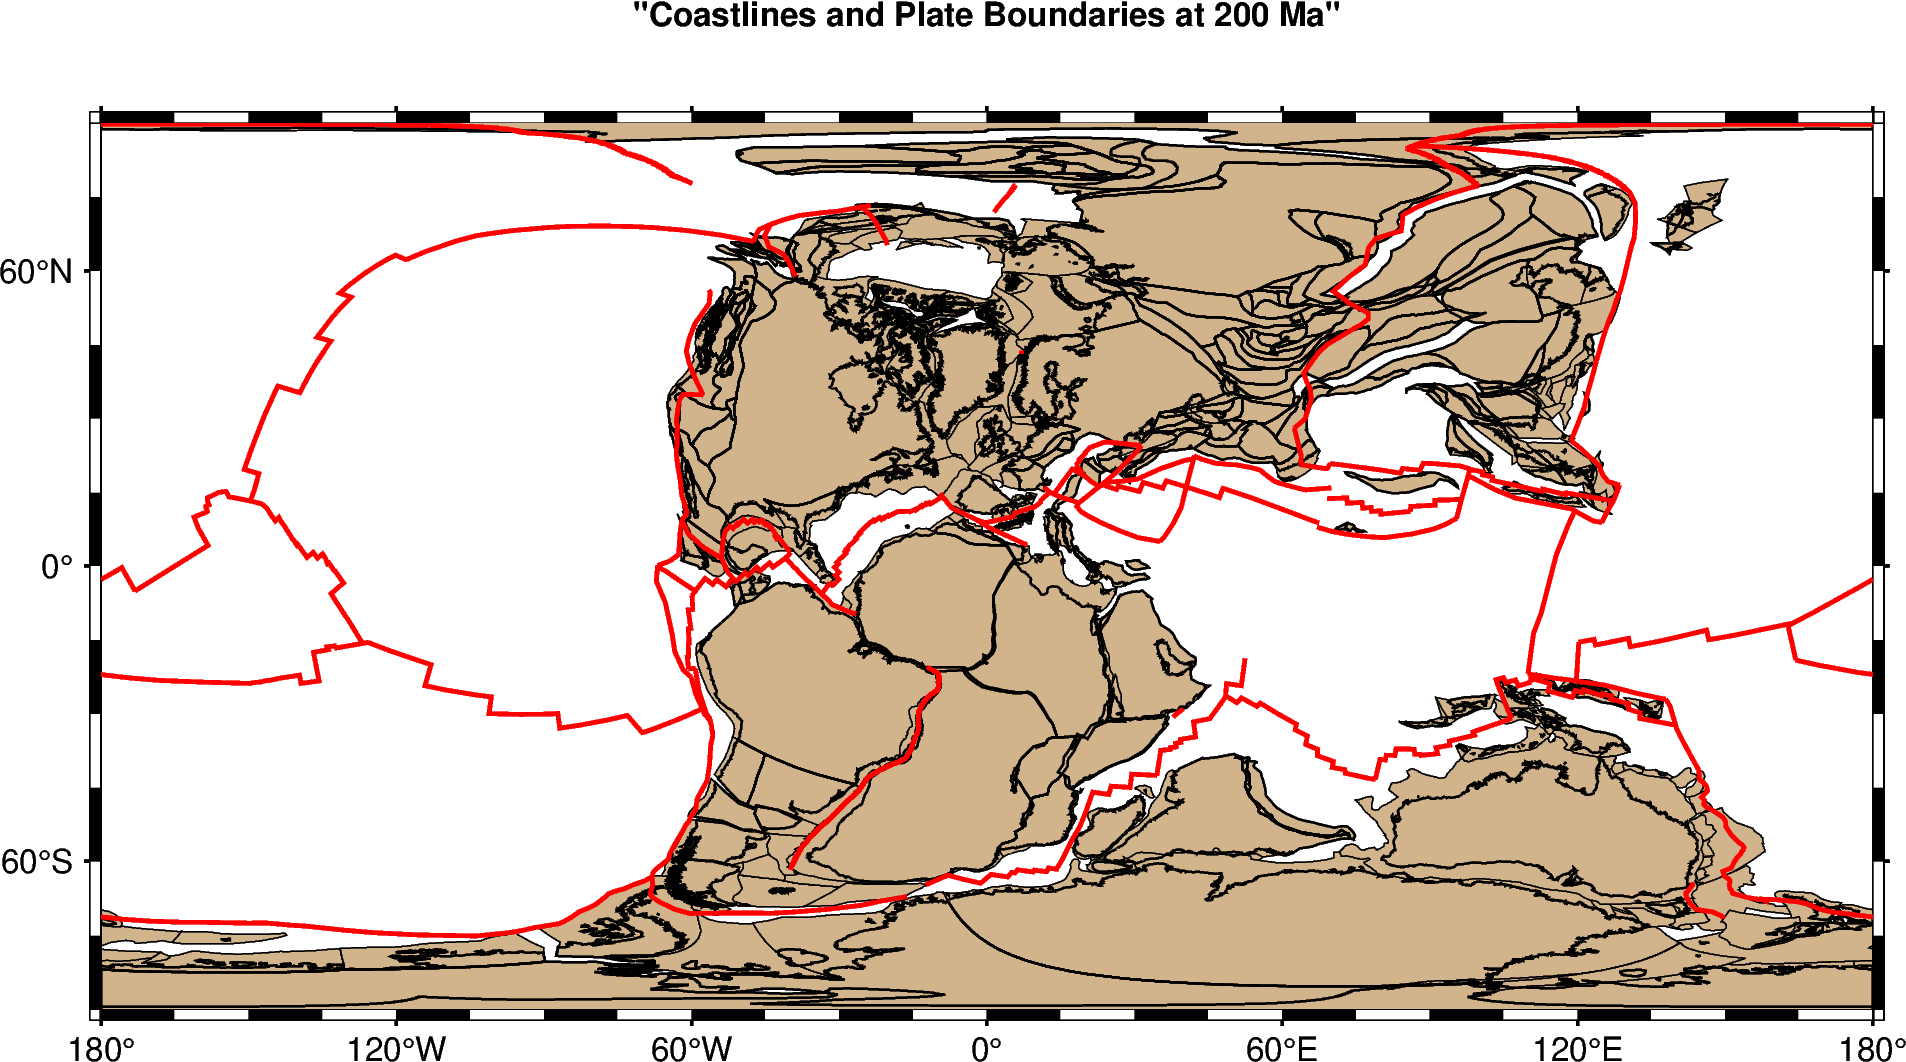

In [19]:
# Get all reconstructed features
coastlines_gdf = gplot.get_coastlines()
continents_gdf = gplot.get_continents()
ridges_gdf = gplot.get_ridges()
transforms_gdf = gplot.get_transforms()
trenches_gdf = gplot.get_trenches()

# Create figure
fig = pygmt.Figure()

# Basemap
fig.basemap(
    region="d",
    projection="Q15c",
    frame=["af", f'+t"Coastlines and Plate Boundaries at {time} Ma"']
)

# Plot reconstructed continents
if continents_gdf is not None and not continents_gdf.empty:
    fig.plot(data=continents_gdf, fill="tan", pen="0.25p,black")

# Plot coastlines
if coastlines_gdf is not None and not coastlines_gdf.empty:
    fig.plot(data=coastlines_gdf, pen="0.5p,black")

# Plot plate boundaries i.e. ridges, transforms, trenches
if ridges_gdf is not None and not ridges_gdf.empty:
    fig.plot(data=ridges_gdf, pen="1p,red", label="Ridges")

if transforms_gdf is not None and not transforms_gdf.empty:
    fig.plot(data=transforms_gdf, pen="1p,red", label="Transforms")

if trenches_gdf is not None and not trenches_gdf.empty:
    fig.plot(data=trenches_gdf, pen="1p,red", label="Trenches")

fig.show()

### Plotting with PyGMT Plotting Engine

Now, let’s look at an example using GPlately’s built-in PyGMT plotting engine instead of setting up the figure manually. This approach is more concise and automatically handles projection, map setup, and layering. This makes it ideal for quick visualizations or exploratory reconstructions!

In this example, we use the Müller (2019) plate model to reconstruct coastlines and plate boundaries at 200 Ma. The `PygmtPlotEngine` integrates seamlessly with `PlotTopologies`, letting you call methods like `plot_coastlines()` or `plot_ridges()` directly on a PyGMT figure.

See: [GPlately documentation on PlotTopologies](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html) if you’d like to dive deeper into the capabilities of the PlotTopologies object!

> `NOTE:` You’ll need to specify map projections using GMT-style syntax (e.g., "Q15c" for a 15 cm-wide Plate Carrée projection). If you’re new to GMT projections, check out the [PyGMT projections documentation](https://www.pygmt.org/v0.3.1/projections/index.html) for a helpful guide.

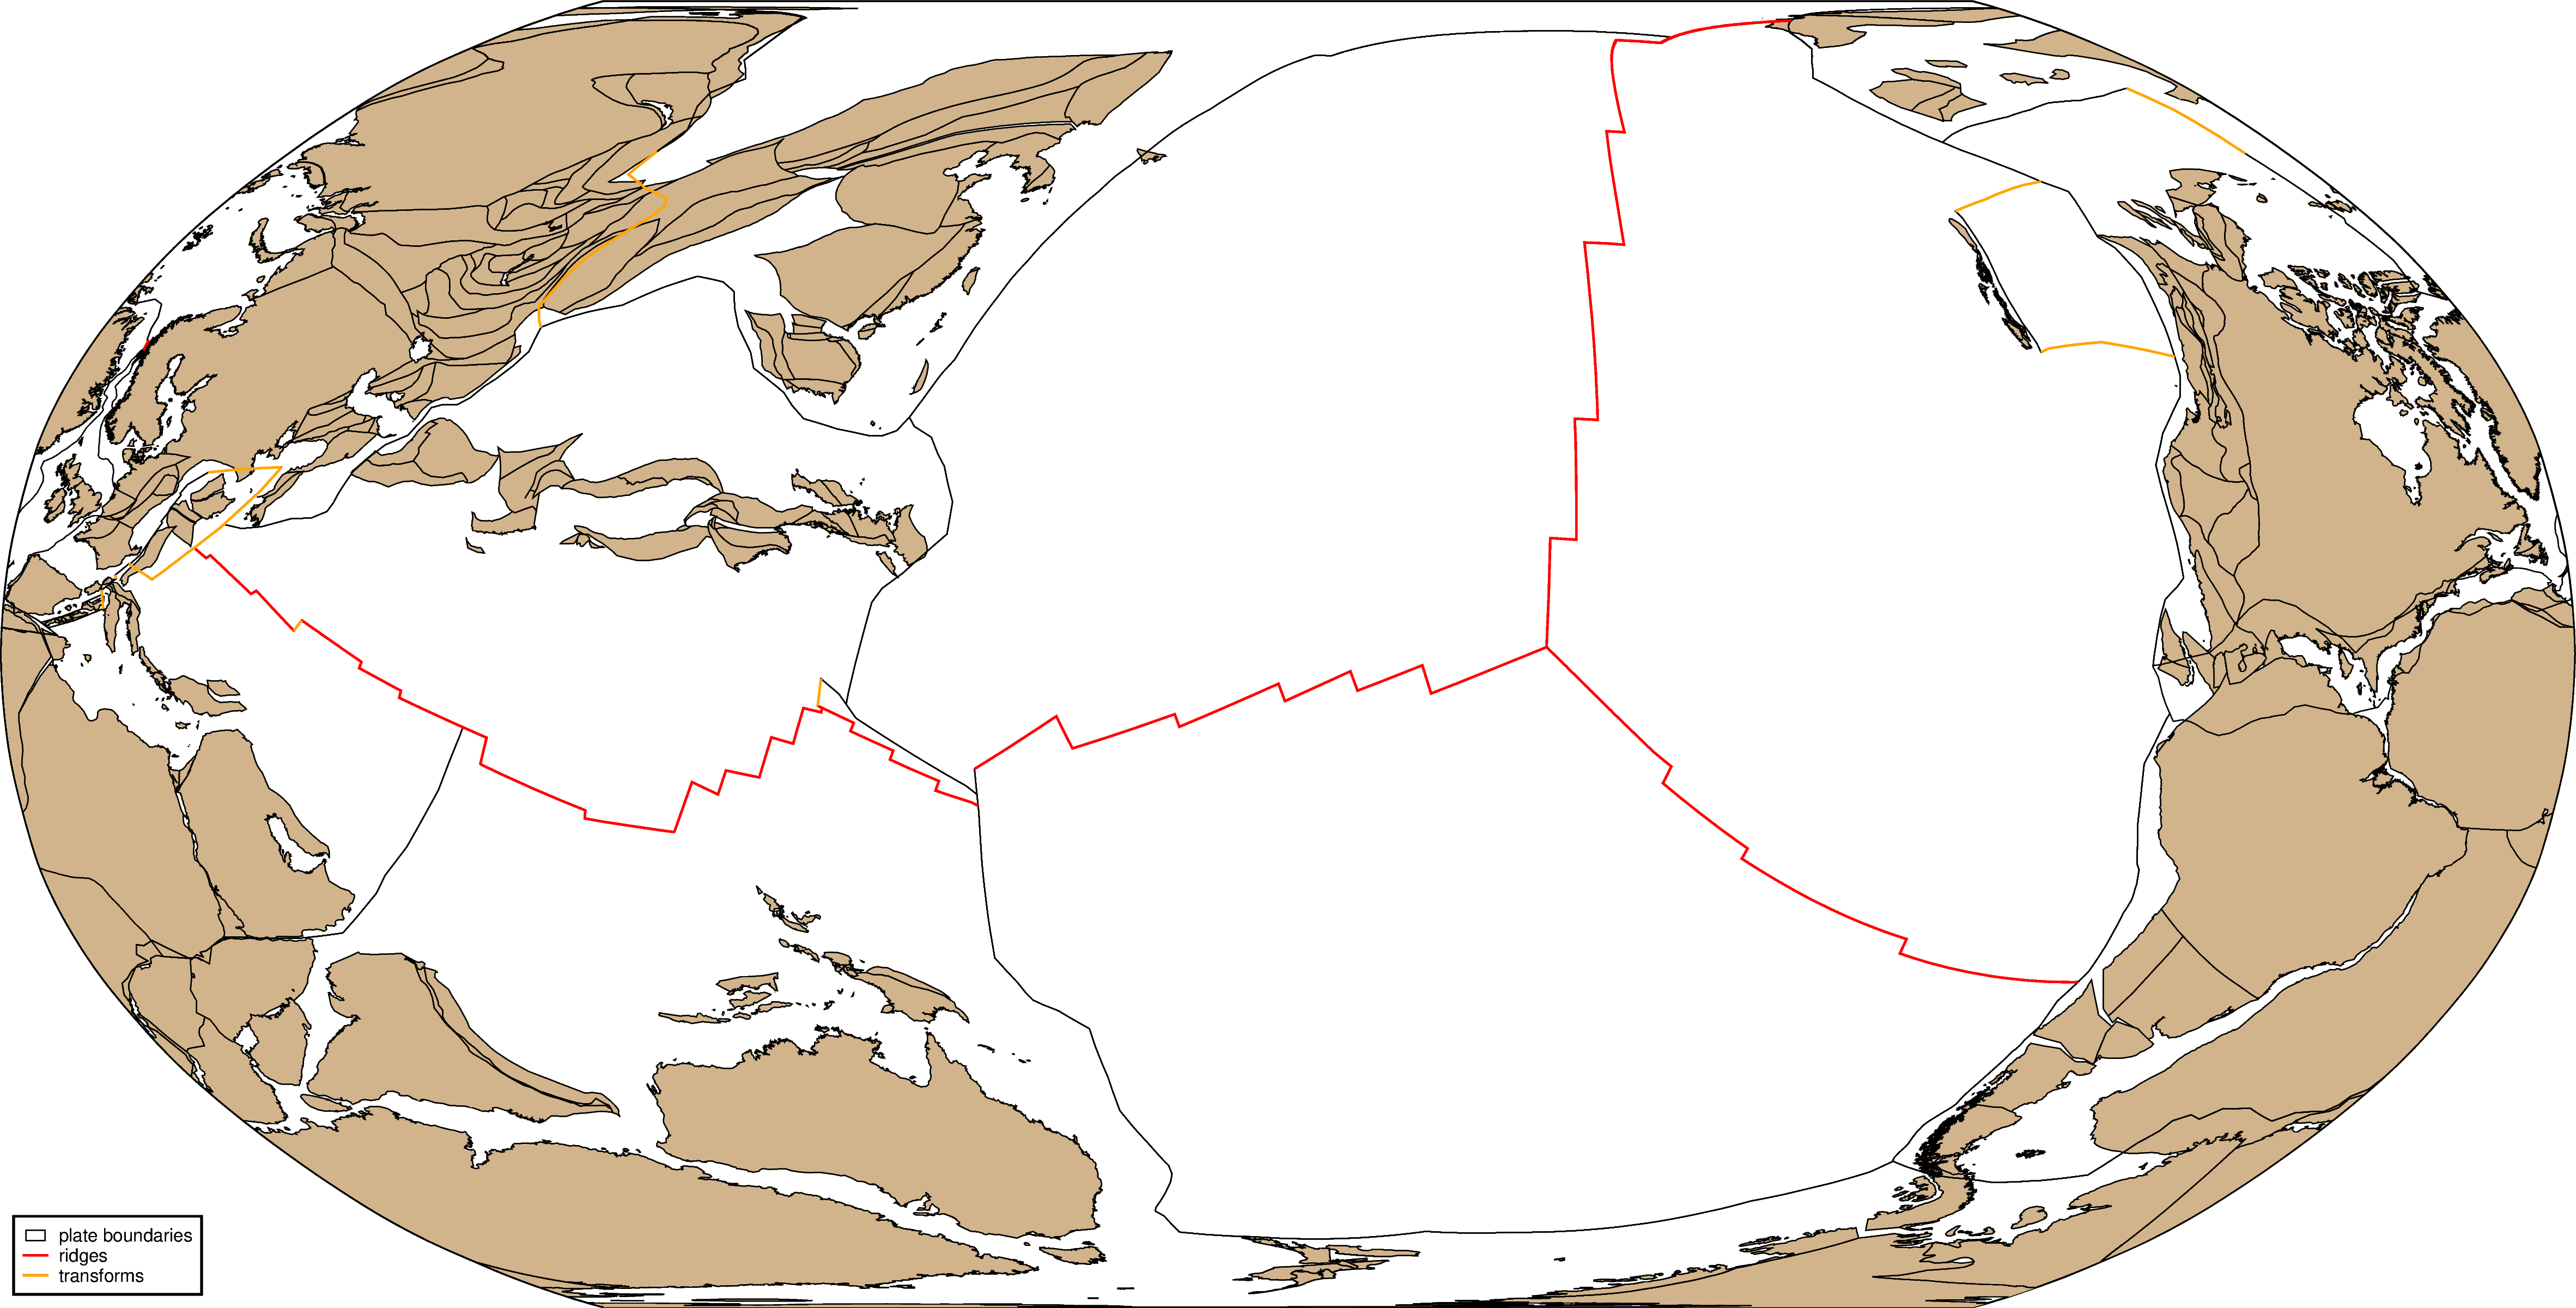

In [ ]:
# Create PlotTopologies object with PygmtPlotEngine
gplot = get_gplot(
    model="Muller2019",  # or "merdith2021"
    model_repo_dir="../../data/plate-model-repo",
    time=200,  # Ma
    plot_engine=PygmtPlotEngine(),
)

# Create basemap figure with PyGMT
# N = Robinson projection
# 15c = 15 cm width
# region="d" means global (-180/180/-90/90)
fig = get_pygmt_basemap_figure(projection="N180/40c", region="d")

# Plot reconstructed features using gplot methods
gplot.plot_coastlines(
    fig, 
    edgecolor="black", 
    facecolor="tan",  # continent fill color
    linewidth=0.5, 
    central_meridian=180
)

gplot.plot_topological_plate_boundaries(
    fig,
    edgecolor="black",
    linewidth=0.5,
    central_meridian=180,
    gmtlabel="plate boundaries",
)

gplot.plot_ridges(
    fig, 
    pen="1p,red", 
    gmtlabel="ridges"
)

gplot.plot_transforms(
    fig, 
    pen="1p,orange", 
    gmtlabel="transforms"
)

# Add legend
fig.legend(
    position="jBL+o0.2c/0.2c",  # Bottom Left with offset
    box="+gwhite+p1p"
)

# Show figure
fig.show(width=1200)